In [27]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [28]:
# Load dataset

df = pd.read_csv("alzheimers_disease_data.csv")

df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [29]:
# Check dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2149
Columns: 35


In [30]:
# Define features and target

X = df.drop(columns=["Diagnosis", "PatientID", "DoctorInCharge"])
y = df["Diagnosis"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2149, 32)
Target shape: (2149,)


In [31]:
# Check target distribution

print(y.value_counts())
print("\nPercentage:")
print(y.value_counts(normalize=True) * 100)

Diagnosis
0    1389
1     760
Name: count, dtype: int64

Percentage:
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64


In [32]:
# Train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1719, 32)
Testing data: (430, 32)


In [33]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
# Create models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}

In [35]:
# Train models

trained_models = {}

for name, model in models.items():
    
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    
    trained_models[name] = model

print("All models trained successfully.")

All models trained successfully.


In [36]:
# Generate predictions

predictions = {}
probabilities = {}

for name, model in trained_models.items():
    
    if name in ["Logistic Regression", "KNN", "SVM"]:
        X_test_model = X_test_scaled
    else:
        X_test_model = X_test
    
    predictions[name] = model.predict(X_test_model)
    probabilities[name] = model.predict_proba(X_test_model)[:, 1]

In [37]:
# Evaluate all models

results = []

for name in trained_models.keys():
    
    y_pred = predictions[name]
    y_prob = probabilities[name]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.816279,0.741722,0.736842,0.739274,0.885365
1,Decision Tree,0.923256,0.883871,0.901316,0.892508,0.909066
2,Random Forest,0.937209,0.937063,0.881579,0.908475,0.939038
3,KNN,0.706977,0.632653,0.407895,0.496000,0.737730
4,SVM,0.834884,0.791367,0.723684,0.756014,0.896287


In [38]:
# Sort models by performance

results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.937209,0.937063,0.881579,0.908475,0.939038
1,Decision Tree,0.923256,0.883871,0.901316,0.892508,0.909066
2,SVM,0.834884,0.791367,0.723684,0.756014,0.896287
3,Logistic Regression,0.816279,0.741722,0.736842,0.739274,0.885365
4,KNN,0.706977,0.632653,0.407895,0.496000,0.737730


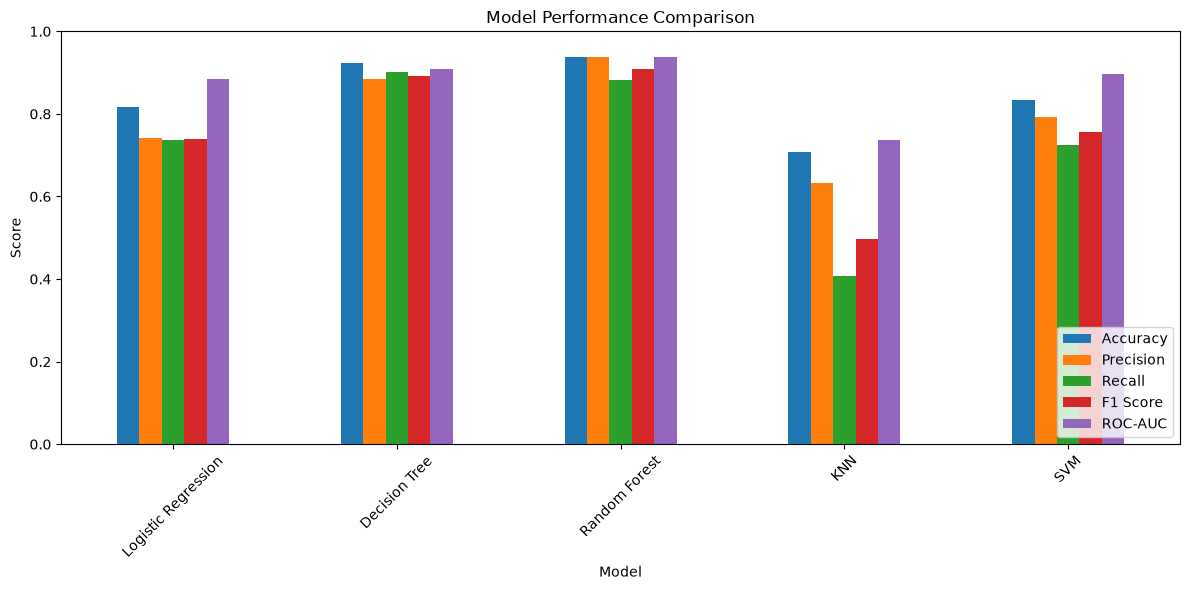

In [39]:
# Plot model comparison

results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [40]:
# Select best model based on F1 Score

best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [41]:
# Classification report for best model

best_predictions = predictions[best_model_name]

print(
    classification_report(
        y_test,
        best_predictions
    )
)

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       278
           1       0.94      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430



[[269   9]
 [ 18 134]]


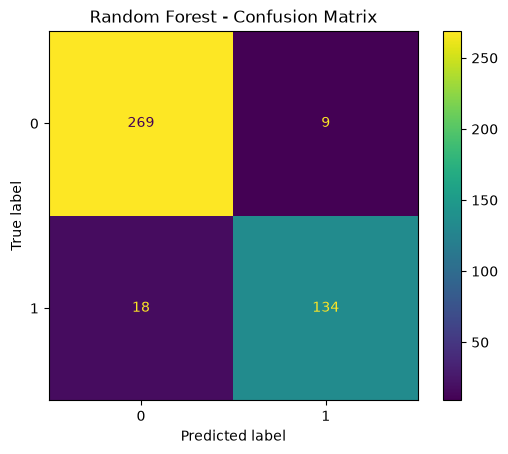

In [42]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    best_predictions
)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title(f"{best_model_name} - Confusion Matrix")
plt.show()

In [43]:
# Hyperparameter tuning - Random Forest

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [44]:
# Best Random Forest model

best_rf = grid_search.best_estimator_

print(best_rf)

RandomForestClassifier(n_estimators=200, random_state=42)


In [45]:
# Final predictions

final_pred = best_rf.predict(X_test)
final_prob = best_rf.predict_proba(X_test)[:, 1]

In [46]:
# Final model evaluation

print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))
print("ROC-AUC  :", roc_auc_score(y_test, final_prob))

Accuracy : 0.9441860465116279
Precision: 0.9444444444444444
Recall   : 0.8947368421052632
F1 Score : 0.918918918918919
ROC-AUC  : 0.9402215070049225


In [47]:
# Final classification report

print(
    classification_report(
        y_test,
        final_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       278
           1       0.94      0.89      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430



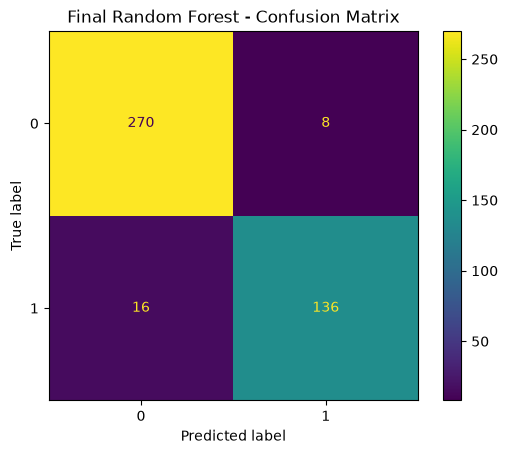

In [48]:
# Final confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred
)

plt.title("Final Random Forest - Confusion Matrix")
plt.show()

In [49]:
# Feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
23,FunctionalAssessment,0.176984
26,ADL,0.165868
22,MMSE,0.118799
24,MemoryComplaints,0.086614
25,BehavioralProblems,0.045326
8,DietQuality,0.032249
7,PhysicalActivity,0.030727
20,CholesterolHDL,0.030709
9,SleepQuality,0.030450
21,CholesterolTriglycerides,0.030265


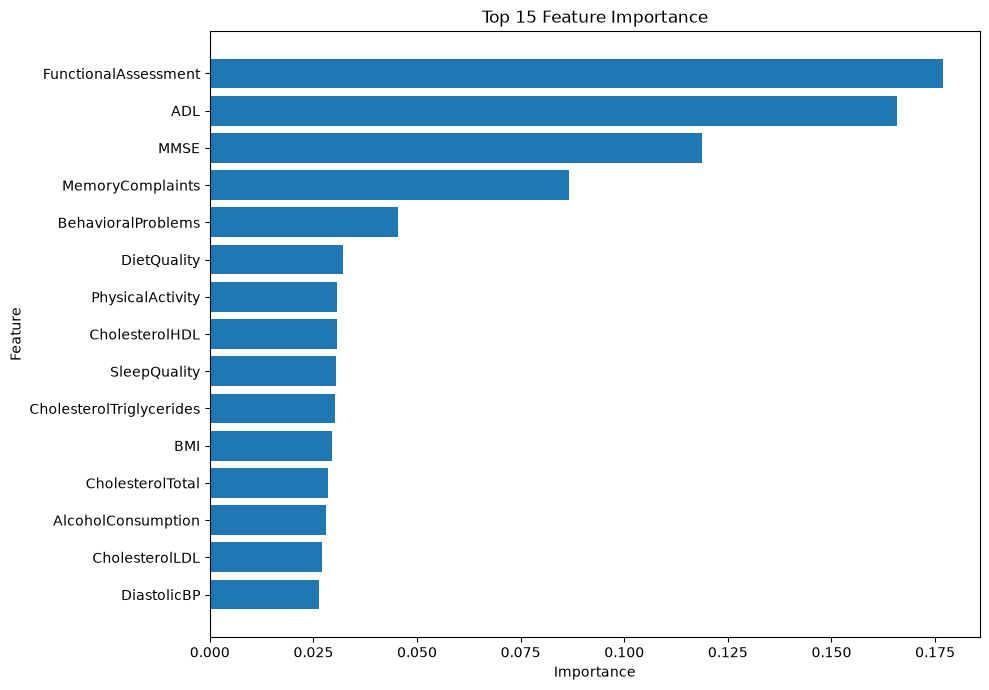

In [50]:
# Plot feature importance

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance")
plt.tight_layout()
plt.show()

In [51]:
# Final model summary

print("Final Model: Random Forest")
print("Best Parameters:", grid_search.best_params_)
print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))
print("ROC-AUC  :", roc_auc_score(y_test, final_prob))

Final Model: Random Forest
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy : 0.9441860465116279
Precision: 0.9444444444444444
Recall   : 0.8947368421052632
F1 Score : 0.918918918918919
ROC-AUC  : 0.9402215070049225
